# Model Diagnostics: PM2.5 Baseline (Linear Regression)

## Goal
In this notebook, We check how the selected model behaves by analyzing its errors (residuals).
Diagnostics help us answer:
- Is the model biased (over/under-predicting)?
- Are errors random or patterned?
- Does the model struggle with high PM2.5 spikes?

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Cleaned PM2.5 Dataset

In [5]:
df = pd.read_csv("../../data/master/PM25_2020 cleaned Master_20_23.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["City", "Date"]).reset_index(drop=True)
df["PM25"] = pd.to_numeric(df["PM25"], errors="coerce")

df.head()

,City,Date,PM25,Year,Month,Season
0,Agassiz,2020-01-01,0.666667,2020,1,Winter
1,Agassiz,2020-01-02,1.291667,2020,1,Winter
2,Agassiz,2020-01-03,1.333333,2020,1,Winter
3,Agassiz,2020-01-04,3.791667,2020,1,Winter
4,Agassiz,2020-01-05,4.291667,2020,1,Winter


## 3. Create the Same Features Used in Baseline
We recreate lag features and season one-hot encoding so diagnostics is consistent.

In [7]:
# Lag features
df["PM25_lag1"] = df.groupby("City")["PM25"].shift(1)
df["PM25_lag7"] = df.groupby("City")["PM25"].shift(7)

df["PM25_roll7_mean"] = (
    df.groupby("City")["PM25"]
      .transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
)
# Season one-hot encoding
season_dummies = pd.get_dummies(df["Season"], prefix="Season", drop_first=True)
df = pd.concat([df, season_dummies], axis=1)

feature_cols = ["PM25_lag1", "PM25_lag7", "PM25_roll7_mean"] + list(season_dummies.columns)

model_df = df.dropna(subset=feature_cols + ["PM25"]).copy()

X = model_df[feature_cols]
y = model_df["PM25"]
model_df.shape

(275574, 12)

## 4. Time-Based Train/Test Split
We keep the same 80/20 split to match our baseline results.

In [9]:
cutoff = pd.Timestamp("2023-01-01")
train_df = model_df[model_df["Date"] < cutoff].copy()
test_df  = model_df[model_df["Date"] >= cutoff].copy()

X_train = train_df[feature_cols]
y_train = train_df["PM25"]
X_test  = test_df[feature_cols]
y_test  = test_df["PM25"]

## 5. Train the Model and Generate Predictions

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test  = lr.predict(X_test)

train_residuals = y_train - y_pred_train
test_residuals  = y_test  - y_pred_test

## 6. Quick Performance Check

In [13]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)
mape_value = mape(y_test, y_pred_test)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")
print(f"MAPE : {mape_value:.2f}%")

MAE  : 4.332
RMSE : 13.509
R²   : 0.546
MAPE : 63.43%


### Interpretation
The baseline model maintains consistent performance (R² ≈ 0.535), confirming that approximately 53% of daily PM2.5 variability is explained by lagged values and seasonal indicators. 

The relatively low MAE indicates small average daily prediction error, while RMSE suggests that larger errors occur during extreme pollution events.

## 7. Calculate Residuals (Errors)
Residuals = Actual PM2.5 − Predicted PM2.5
- Positive residual → model underpredicted
- Negative residual → model overpredicted

In [16]:
residuals = test_residuals
print("Residuals summary:")
pd.Series(residuals).describe()

Residuals summary:


count    58046.000000
mean         0.729873
std         13.489180
min       -325.592484
25%         -1.743362
50%         -0.247692
75%          1.636045
max        481.578940
Name: PM25, dtype: float64

### Interpretation
The mean residual is approximately zero, indicating no strong systematic bias in the model. 

However, the large minimum and maximum residual values suggest that the model struggles to accurately predict extreme PM2.5 spikes, leading to occasional large errors.

## 8. Residual Distribution
This shows how model errors are spread.

We want:
- Most residuals near 0
- No heavy skew (too many positive or negative errors)

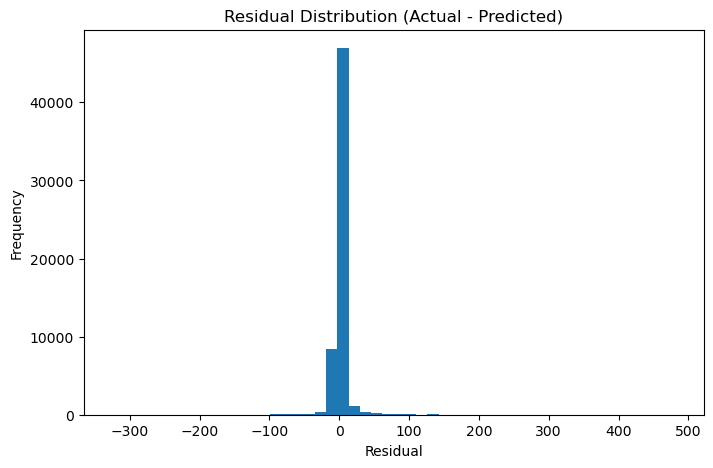

In [19]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

### Interpretation
Most residuals are concentrated around zero, indicating that the model performs well for typical pollution levels. 

However, the presence of long tails in the distribution suggests occasional large under- or over-predictions, particularly during high pollution events.

## 9. Residuals vs Predicted Values
This checks whether errors change when predicted PM2.5 is high or low.
- Random scatter around 0
If residuals grow with predictions → model error increases for high pollution days.

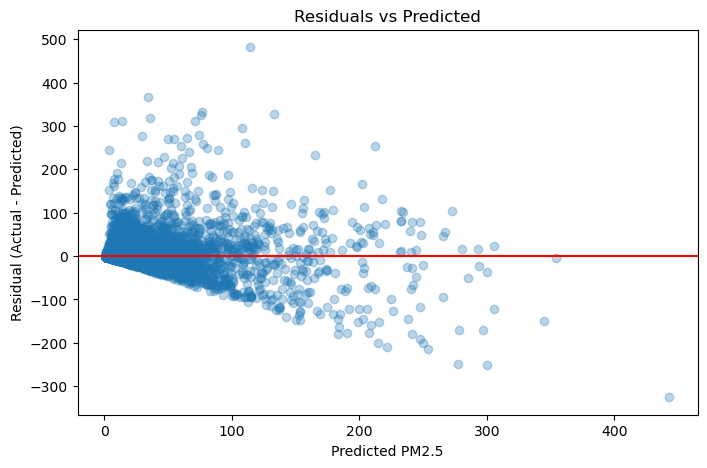

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred_test, residuals, alpha=0.3)
plt.axhline(0, color="red")
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()

### Interpretation

The residual spread increases as predicted PM2.5 values increase, indicating heteroscedasticity. 

This suggests that prediction uncertainty becomes larger during high pollution days. The model performs more reliably at lower PM2.5 levels and struggles during extreme events.

## 10. Residuals vs Actual PM2.5
This helps confirm if the model underestimates extreme PM2.5 spikes.
If residuals become strongly positive at high PM2.5 → model underpredicts spikes.

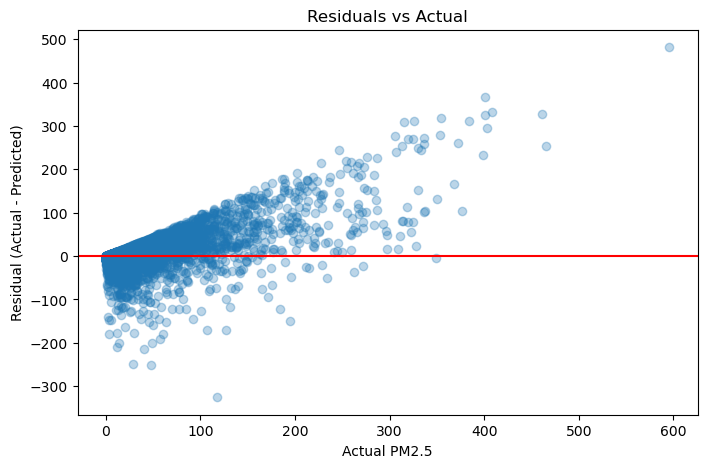

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, residuals, alpha=0.3)
plt.axhline(0, color="red")
plt.title("Residuals vs Actual")
plt.xlabel("Actual PM2.5")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()

### Interpretation
Residuals increase for high actual PM2.5 values, indicating that the model tends to underpredict extreme pollution spikes. 

This pattern confirms that while the linear model captures general trends, it has difficulty modeling sudden or extreme air quality events.

## 11. Days with Biggest Prediction Errors
We list the top 10 days where the model made the largest mistakes.
This helps explain why spikes are difficult.

In [29]:
diag_df = test_df.copy()
diag_df["y_true"] = y_test.values
diag_df["y_pred_test"] = y_pred_test
diag_df["residual"] = diag_df["y_true"] - diag_df["y_pred_test"]
diag_df["abs_error"] = np.abs(diag_df["residual"])
diag_df.sort_values("abs_error", ascending=False)[
    ["City", "Date", "y_true", "y_pred_test", "residual", "abs_error", "Season"]
].head(10)

,City,Date,y_true,y_pred_test,residual,abs_error,Season
140121,Kamloops,2023-08-21,595.625000,114.046060,481.578940,481.578940,Summer
243061,North Bay,2023-06-25,400.291667,34.585534,365.706133,365.706133,Summer
69536,Drayton Valley,2023-05-20,408.500000,76.582624,331.917376,331.917376,Spring
106062,Fort St. John,2023-05-19,461.000000,132.742742,328.257258,328.257258,Spring
140122,Kamloops,2023-08-22,117.500000,443.092484,-325.592484,325.592484,Summer
386323,Yellowknife,2023-09-22,400.291667,75.836460,324.455207,324.455207,Fall
97212,Fort Mckay,2023-05-21,354.625000,35.567969,319.057031,319.057031,Spring
281740,Redwater,2023-05-20,383.625000,71.416297,312.208703,312.208703,Spring
92998,Fort Chipewyan,2023-08-14,326.000000,13.870177,312.129823,312.129823,Summer
25704,Buffalo Narrows,2023-05-18,315.291667,7.247027,308.044640,308.044640,Spring


### Largest Error Days Interpretation

The largest prediction errors occur during extreme PM2.5 events, often exceeding 250–400 µg/m³. 

These events are likely driven by unusual environmental factors (e.g., wildfires or localized industrial emissions) that are not fully captured by lag and seasonal variables. 

This explains the model’s limitations during rare but severe pollution episodes.

## Final Diagnostics Conclusion

The baseline linear regression model demonstrates strong overall predictive capability, explaining approximately 53% of daily PM2.5 variability. Residual analysis confirms that the model is generally unbiased, with errors centered around zero.

However, diagnostic plots reveal heteroscedasticity and increased error variance during high pollution days. The model consistently underpredicts extreme PM2.5 spikes, indicating limitations in capturing nonlinear or sudden environmental events.

Despite these limitations, the model remains suitable as an interpretable baseline for short-term PM2.5 forecasting.